# Sentiment Analysis

In [1]:
# !pip install wordcloud
# !pip install vaderSentiment-fr

import ast
import numpy as np
import pandas as pd
import seaborn as sns
import datetime
import warnings
from datetime import date, timedelta
from matplotlib import pyplot as plt
from wordcloud import WordCloud
from tqdm import tqdm

In [2]:
# Import

df = pd.read_csv('preprocessed_data.csv')
df['Date']     = pd.to_datetime(df['Date']).dt.date
df['Creation'] = pd.to_datetime(df['Creation']).dt.date
df.sort_values('Date', inplace=True)
df.info()
df.sample(10, random_state = 123)

<class 'pandas.core.frame.DataFrame'>
Index: 56219 entries, 0 to 56218
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       56219 non-null  object
 1   Comment    56219 non-null  object
 2   Reply      56219 non-null  int64 
 3   Retweet    56219 non-null  int64 
 4   Like       56219 non-null  int64 
 5   Quote      56219 non-null  int64 
 6   Creation   56219 non-null  object
 7   Place      39387 non-null  object
 8   Followers  56219 non-null  int64 
 9   Leader     56219 non-null  object
 10  Raw_Tweet  56219 non-null  object
dtypes: int64(5), object(6)
memory usage: 5.1+ MB


,Date,Comment,Reply,Retweet,Like,Quote,Creation,Place,Followers,Leader,Raw_Tweet
26017,2018-12-10,"['avoir', 'tjrs', 'avoir', 'bcp', 'respect', '...",1,0,0,0,2018-09-01,Kenya,16,Fayulu,@StanysBujakera @LubayaClaudel @DSESANGA @Ense...
32230,2018-12-12,"['rdc', 'candidat', 'maurice', 'masheke', 'inv...",0,0,0,0,2018-02-22,République Démocratique Du Con,112,Fayulu,Rdc : Le candidat Maurice Masheke invite les c...
8593,2018-11-26,"['hahaha', 'avoir', 'enterrer', 'papa', 'autru...",2,0,1,0,2016-02-09,RDC🇨🇩🇨🇩,34941,Fayulu,@tresinsolent @Brielyoka @YNdjoli @moise_katum...
43578,2018-12-19,"['ami', 'cela', 'être', 'distraction', 'reveni...",0,2,3,0,2017-02-24,République Démocratique Du Congo,290,Fayulu,@lec_2001 @damkup @jmilunga @juantedbelkas @Ed...
53894,2018-12-30,"['okufi', 'nayo', 'ndeko', 'ted', 'beleshay', ...",0,0,1,0,2016-05-10,Congo Kinshasa,1307,Tshisekedi,@juantedbelkas @MartinFayulu @fatshi13 Okufi n...
43321,2018-12-19,"['cher', 'ami', 'rejoindre', 'vérité', 'avant'...",0,0,0,0,2013-02-01,NaN,1962,Fayulu,"Chers amis, rejoignez la vérité avant qu’il ne..."
36759,2018-12-15,"['fayulu', 'être', 'porte', 'parole', 'muzito'...",0,0,0,0,2018-09-01,NaN,2748,Fayulu,@BNC_2012 @INSOUMISERDC @LithoLeja Fayulu en s...
17951,2018-12-05,"['accueil', 'triompant', 'exceptionnel', 'mart...",0,0,3,0,2012-01-23,United Kingdom,851,Fayulu,L’ACCUEIL TRIOMPANT ET EXCEPTIONNEL DE MARTIN ...
29058,2018-12-11,"['grand', 'mobilisation', 'accueillir', 'marti...",0,0,0,0,2013-08-30,RDCONGO,477,Fayulu,Grande mobilisation pour accueillir Martin Fay...
22908,2018-12-08,"['emmanuel', 'shadary', 'reste', 'sou', 'sanct...",0,3,1,0,2015-01-13,NaN,567,Ramazani,EMMANUEL SHADARY RESTE SOUS SANCTIONS .\n\nDes...


In [3]:
# Convert the string representation of lists to actual lists

def clean_comment_text(comment):
    if isinstance(comment, str):
        try:
            # Convert string representation of list to actual list
            word_list = ast.literal_eval(comment)
            # Join the words with spaces
            return ' '.join(word_list)
        except:
            # If conversion fails, return as is (but remove brackets and quotes)
            return comment.replace("'", "").replace("[", "").replace("]", "")
    elif isinstance(comment, list):
        # If it's already a list, just join it
        return ' '.join(comment)
    else:
        return str(comment)

In [4]:
# Apply the cleaning function to the Comment column
df['Comment'] = df['Comment'].apply(clean_comment_text)
df.sample(10, random_state = 123)

,Date,Comment,Reply,Retweet,Like,Quote,Creation,Place,Followers,Leader,Raw_Tweet
26017,2018-12-10,avoir tjrs avoir bcp respect delly sessanga cl...,1,0,0,0,2018-09-01,Kenya,16,Fayulu,@StanysBujakera @LubayaClaudel @DSESANGA @Ense...
32230,2018-12-12,rdc candidat maurice masheke invite chrétien v...,0,0,0,0,2018-02-22,République Démocratique Du Con,112,Fayulu,Rdc : Le candidat Maurice Masheke invite les c...
8593,2018-11-26,hahaha avoir enterrer papa autrui être méchant...,2,0,1,0,2016-02-09,RDC🇨🇩🇨🇩,34941,Fayulu,@tresinsolent @Brielyoka @YNdjoli @moise_katum...
43578,2018-12-19,ami cela être distraction revenir mouton fayul...,0,2,3,0,2017-02-24,République Démocratique Du Congo,290,Fayulu,@lec_2001 @damkup @jmilunga @juantedbelkas @Ed...
53894,2018-12-30,okufi nayo ndeko ted beleshay félix tshisekedi...,0,0,1,0,2016-05-10,Congo Kinshasa,1307,Tshisekedi,@juantedbelkas @MartinFayulu @fatshi13 Okufi n...
43321,2018-12-19,cher ami rejoindre vérité avant ne être trop t...,0,0,0,0,2013-02-01,NaN,1962,Fayulu,"Chers amis, rejoignez la vérité avant qu’il ne..."
36759,2018-12-15,fayulu être porte parole muzito avoir dire,0,0,0,0,2018-09-01,NaN,2748,Fayulu,@BNC_2012 @INSOUMISERDC @LithoLeja Fayulu en s...
17951,2018-12-05,accueil triompant exceptionnel martin fayulu b...,0,0,3,0,2012-01-23,United Kingdom,851,Fayulu,L’ACCUEIL TRIOMPANT ET EXCEPTIONNEL DE MARTIN ...
29058,2018-12-11,grand mobilisation accueillir martin fayulu lu...,0,0,0,0,2013-08-30,RDCONGO,477,Fayulu,Grande mobilisation pour accueillir Martin Fay...
22908,2018-12-08,emmanuel shadary reste sou sanction responsabl...,0,3,1,0,2015-01-13,NaN,567,Ramazani,EMMANUEL SHADARY RESTE SOUS SANCTIONS .\n\nDes...


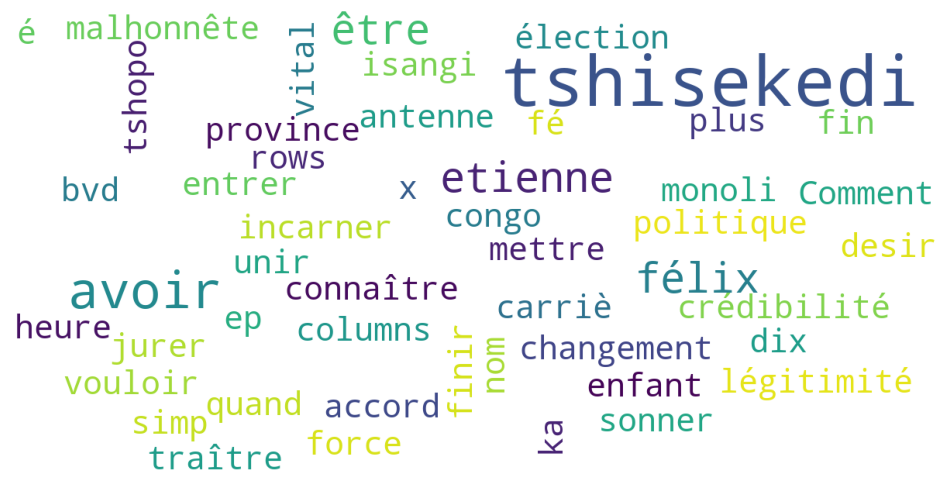

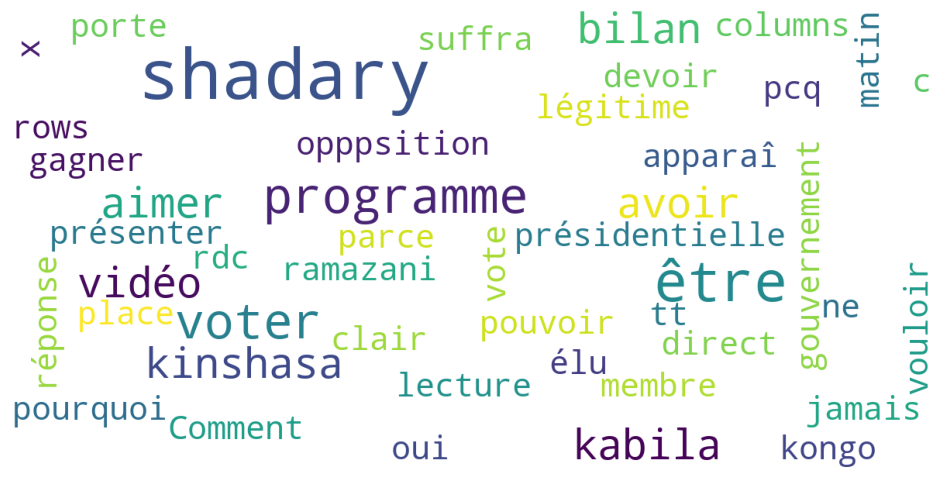

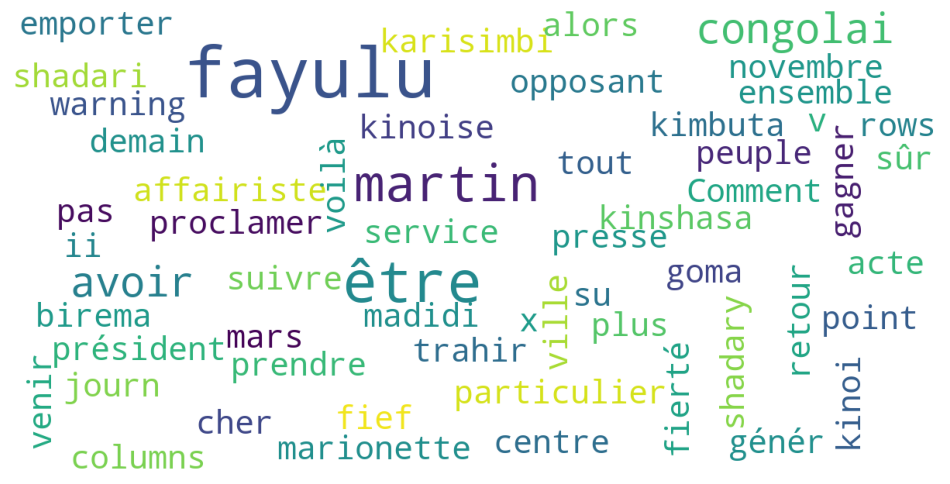

In [29]:
# Word cloud

def show_wordcloud(data, text):
    wordcloud = WordCloud(
        background_color = 'white',
        max_words = 100,
        max_font_size = 30,
        scale = 3,
        random_state = 1)

    wordcloud = wordcloud.generate(str(data))

    fig = plt.figure(1, figsize = (12,12))
    plt.axis('off')

    plt.imshow(wordcloud)
    plt.title(str(text))
    plt.show()

show_wordcloud(data = df.loc[df['Leader'] == 'Tshisekedi', ['Comment']], text='')
show_wordcloud(data = df.loc[df['Leader'] == 'Ramazani', ['Comment']], text='')
show_wordcloud(data = df.loc[df['Leader'] == 'Fayulu', ['Comment']], text='')

## VADER

In [6]:
from vaderSentiment_fr.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

c:\Users\hp\.conda\envs\myenv\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [7]:
# Sentiment scores using French-VADER

df[["Polarity", "Subjectivity"]] = df["Comment"].apply(lambda text: pd.Series(TextBlob(text).sentiment))

for index, row in tqdm(df["Comment"].items(), total=len(df)):
    sia = SentimentIntensityAnalyzer()
    score = sia.polarity_scores(row)
    neg = score["neg"]
    neu = score["neu"]
    pos = score["pos"]
    if neg > pos:
        df.loc[index, "Sentiment_VADER"] = "negative"
    elif neg < pos:
        df.loc[index, "Sentiment_VADER"] = "positive"
    else:
        df.loc[index, "Sentiment_VADER"] = "neutral"

display(df["Sentiment_VADER"].value_counts(normalize = True))
display(df.sample(10, random_state = 123))

100%|██████████| 56219/56219 [1:49:26<00:00,  8.56it/s]  


Sentiment_VADER
positive    0.462299
negative    0.319714
neutral     0.217987
Name: proportion, dtype: float64

,Date,Comment,Reply,Retweet,Like,Quote,Creation,Place,Followers,Leader,Raw_Tweet,Polarity,Subjectivity,Sentiment_VADER
26017,2018-12-10,avoir tjrs avoir bcp respect delly sessanga cl...,1,0,0,0,2018-09-01,Kenya,16,Fayulu,@StanysBujakera @LubayaClaudel @DSESANGA @Ense...,0.0,0.0,positive
32230,2018-12-12,rdc candidat maurice masheke invite chrétien v...,0,0,0,0,2018-02-22,République Démocratique Du Con,112,Fayulu,Rdc : Le candidat Maurice Masheke invite les c...,0.0,0.0,neutral
8593,2018-11-26,hahaha avoir enterrer papa autrui être méchant...,2,0,1,0,2016-02-09,RDC🇨🇩🇨🇩,34941,Fayulu,@tresinsolent @Brielyoka @YNdjoli @moise_katum...,0.2,0.4,negative
43578,2018-12-19,ami cela être distraction revenir mouton fayul...,0,2,3,0,2017-02-24,République Démocratique Du Congo,290,Fayulu,@lec_2001 @damkup @jmilunga @juantedbelkas @Ed...,0.0,0.0,negative
53894,2018-12-30,okufi nayo ndeko ted beleshay félix tshisekedi...,0,0,1,0,2016-05-10,Congo Kinshasa,1307,Tshisekedi,@juantedbelkas @MartinFayulu @fatshi13 Okufi n...,0.0,0.0,positive
43321,2018-12-19,cher ami rejoindre vérité avant ne être trop t...,0,0,0,0,2013-02-01,NaN,1962,Fayulu,"Chers amis, rejoignez la vérité avant qu’il ne...",0.0,0.0,positive
36759,2018-12-15,fayulu être porte parole muzito avoir dire,0,0,0,0,2018-09-01,NaN,2748,Fayulu,@BNC_2012 @INSOUMISERDC @LithoLeja Fayulu en s...,0.0,0.0,neutral
17951,2018-12-05,accueil triompant exceptionnel martin fayulu b...,0,0,3,0,2012-01-23,United Kingdom,851,Fayulu,L’ACCUEIL TRIOMPANT ET EXCEPTIONNEL DE MARTIN ...,0.0,0.0,positive
29058,2018-12-11,grand mobilisation accueillir martin fayulu lu...,0,0,0,0,2013-08-30,RDCONGO,477,Fayulu,Grande mobilisation pour accueillir Martin Fay...,0.5,1.0,positive
22908,2018-12-08,emmanuel shadary reste sou sanction responsabl...,0,3,1,0,2015-01-13,NaN,567,Ramazani,EMMANUEL SHADARY RESTE SOUS SANCTIONS .\n\nDes...,0.0,0.0,positive


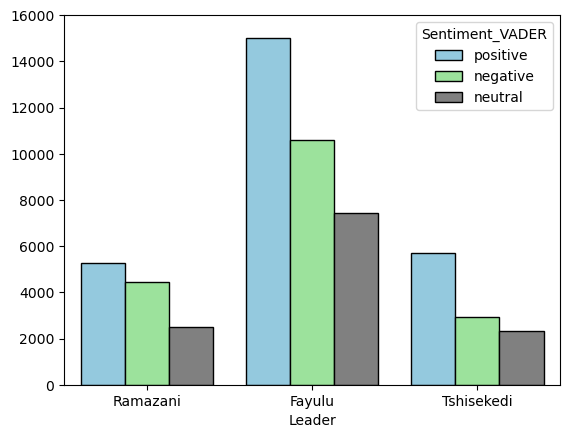

In [31]:
# Sentiment plot (1/4)

#plt.style.use('classic')
sns.countplot(data=df, x='Leader', hue='Sentiment_VADER', palette=['skyblue', 'lightgreen', 'gray'], edgecolor='black')
plt.ylim(0,16000)
plt.ylabel('');

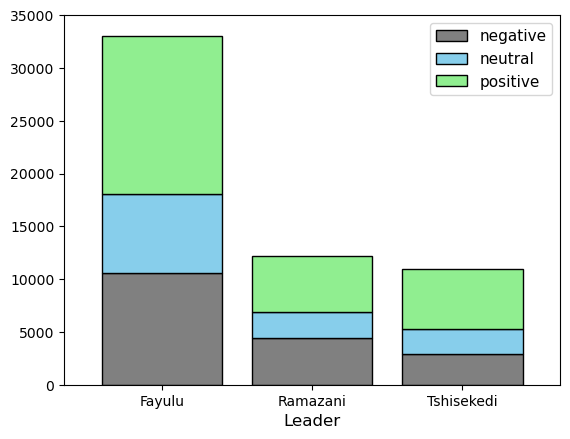

In [49]:
# Sentiment plot (2/4)

data_pivot = df.pivot_table(values = 'Quote', index='Leader', columns='Sentiment_VADER', aggfunc = "count")
data_pivot.plot(kind = 'bar', stacked = True, color = ['gray', 'skyblue', 'lightgreen'], edgecolor='black', width=0.8)
#plt.title('Cumulative number of tweets by sentiment type per leader', fontsize = 9, fontstyle = 'oblique', weight = 'bold')
plt.xticks(rotation = 360)
plt.ylim(0, 35000)
plt.xlabel('Leader', fontsize=12)
plt.legend(title='', fontsize=11)
plt.savefig('cumulative_number_of_tweets_following_the_sentiment_nature.pdf', bbox_inches = 'tight', pad_inches = .1);

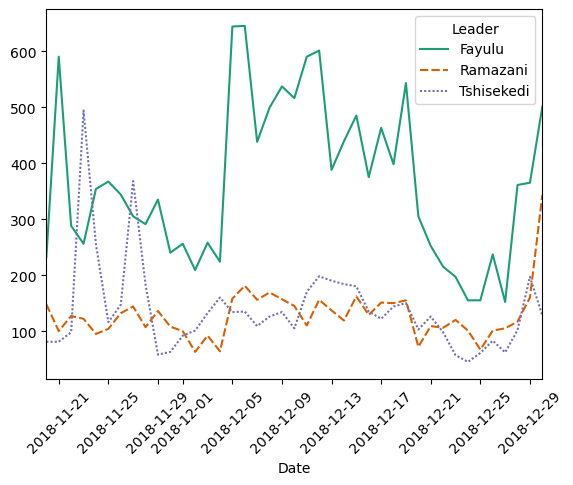

In [10]:
# Sentiment plot (3/4)

sns.lineplot(data = df.loc[df['Sentiment_VADER'] == 'positive'].pivot_table(values = "Quote", columns = "Leader",
                                                                      index = "Date", aggfunc = "count"),
             palette = 'Dark2')
#plt.title('Evolution du nombre de tweets positifs par leader')
plt.xticks(rotation=45)
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.savefig('evolution_of_the_number_of_positive_tweets.pdf', bbox_inches = 'tight', pad_inches = .1);

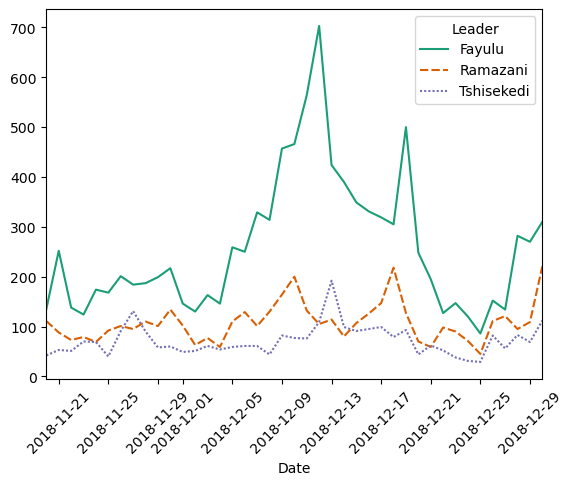

In [11]:
# Sentiment plot (4/4)

sns.lineplot(data = df.loc[df['Sentiment_VADER'] == 'negative'].pivot_table(values = "Quote", columns = "Leader",
                                                                      index = "Date", aggfunc = "count"),
             palette = 'Dark2')
#plt.title('Evolution du nombre de tweets negatifs par leader')
plt.xticks(rotation=45)
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.savefig('evolution_of_the_number_of_negative_tweets.pdf', bbox_inches = 'tight', pad_inches = .1);

                 Polarity  Subjectivity
Sentiment_VADER                        
negative        -0.006944      0.116671
neutral         -0.006170      0.062406
positive         0.016158      0.150445


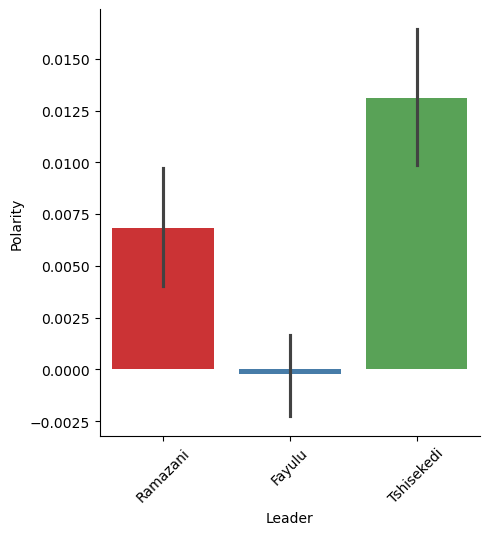

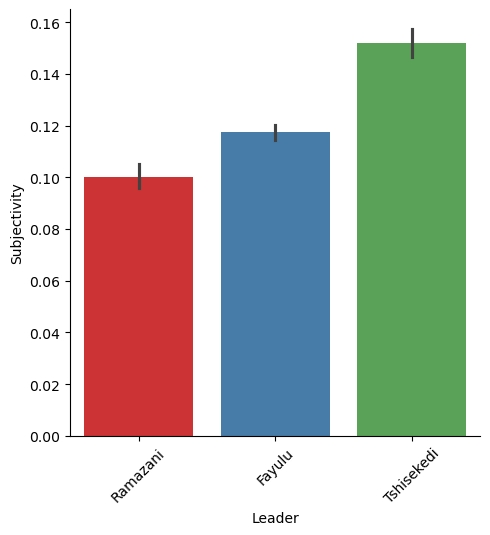

In [12]:
# Polarity vs Subjectivity

print(df[['Polarity', 'Subjectivity', 'Sentiment_VADER']].groupby("Sentiment_VADER").mean())
sns.catplot(data=df, hue="Leader", x="Leader", y="Polarity", kind="bar", palette='Set1').set_xticklabels(rotation = 45)
plt.savefig('polarity_plot.pdf', bbox_inches = 'tight', pad_inches = .1)
sns.catplot(data=df, hue="Leader", x="Leader", y="Subjectivity", kind="bar", palette='Set1').set_xticklabels(rotation = 45)
plt.savefig('subjectivity_plot.pdf', bbox_inches = 'tight', pad_inches = .1);

In [13]:
# Moving average subjectivity per leader

def moving_average_subjectivity(df, date_col='Date', group_col='Leader',
                                subj_col='Subjectivity', window=3, step=1,
                                align='right'):
    """
    Return a DataFrame of moving-average subjectivity for a given grouping column.

    Parameters:
    - df: Input DataFrame containing date, grouping column, and subjectivity columns.
    - date_col: Name of the date column (default 'Date').
    - group_col: Name of the column to group by, e.g., 'Leader' or 'Sentiment_VADER' (default 'Leader').
    - subj_col: Name of the subjectivity column (default 'Subjectivity').
    - window: Rolling window size in days (e.g., 3, 5, 7).
    - step: Sampling step in days (integer >=1, default 1 for daily sampling).
    - align: 'right' or 'center' for rolling alignment (default 'right').

    Returns:
    - DataFrame with dates as index and groups as columns.
    """
    # Ensure date column is datetime
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    # Daily average subjectivity per group (dates as index, groups as columns)
    daily = (df
             .groupby([df[date_col].dt.normalize(), group_col])[subj_col]
             .mean()
             .unstack(group_col)
             .sort_index())

    # Choose rolling center/right alignment
    if align == 'center':
        rolled = daily.rolling(window=window, min_periods=1, center=True).mean()
    else:
        rolled = daily.rolling(window=window, min_periods=1).mean()  # right by default

    # Sample by step (every `step` rows)
    sampled = rolled.iloc[::step, :].copy()
    sampled.index.name = 'Date'

    return sampled

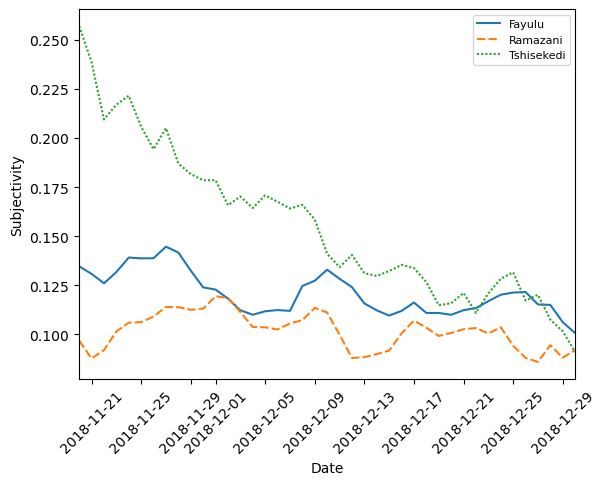

In [14]:
# Calculate 5-day moving average subjectivity per leader

ma_by_leader = moving_average_subjectivity(df, group_col='Leader', window=5, step=1, align='right')

sns.lineplot(data=ma_by_leader, palette='tab10')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.legend(fontsize=8, title='')
plt.ylabel('Subjectivity')
plt.xticks(rotation=45)
plt.savefig('ma_subjectivity_per_leader.pdf', bbox_inches='tight', pad_inches=.1);

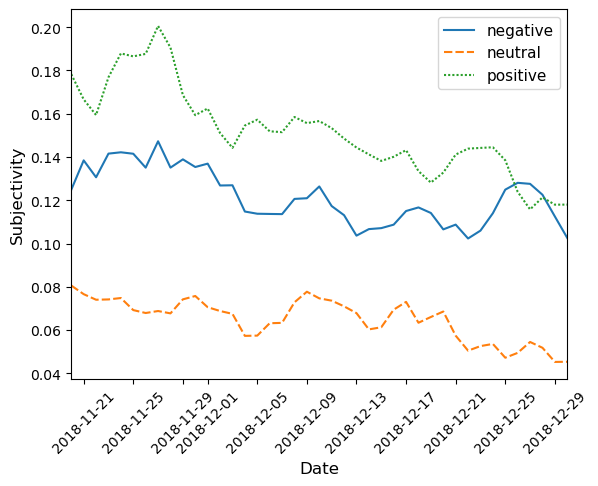

In [48]:
# Calculate 5-day moving average subjectivity per sentiment

ma_by_sentiment_vader=moving_average_subjectivity(df,group_col='Sentiment_VADER',window=5,step=1,align='right')

sns.lineplot(data=ma_by_sentiment_vader, palette='tab10')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.legend(fontsize=11, title='')
plt.ylabel('Subjectivity', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.xticks(rotation=45)
plt.savefig('ma_subjectivity_per_sentiment_vader.pdf', bbox_inches='tight', pad_inches=.1);

Reply           0.0052
Retweet        -0.0042
Like           -0.0020
Quote          -0.0002
Subjectivity    1.0000
Name: Subjectivity, dtype: float64

<Axes: >

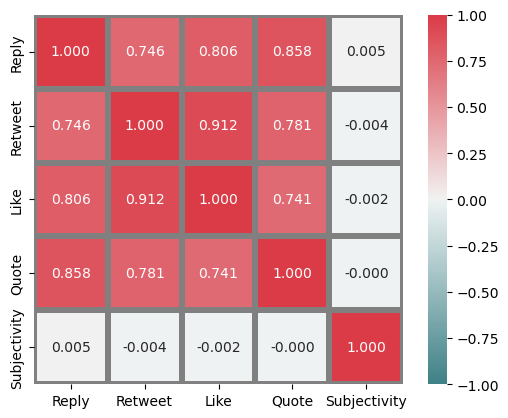

In [16]:
# Correlation analysis: amplification vs subjectivity

corr_data = df[['Reply', 'Retweet', 'Like', 'Quote', 'Subjectivity']]
corr_matrix = corr_data.corr()
display(corr_matrix['Subjectivity'].round(4))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, center=0, cmap=sns.diverging_palette(200, 10, as_cmap=True),
            square=True, annot=True, fmt=".3f", linewidths=4, linecolor="gray")

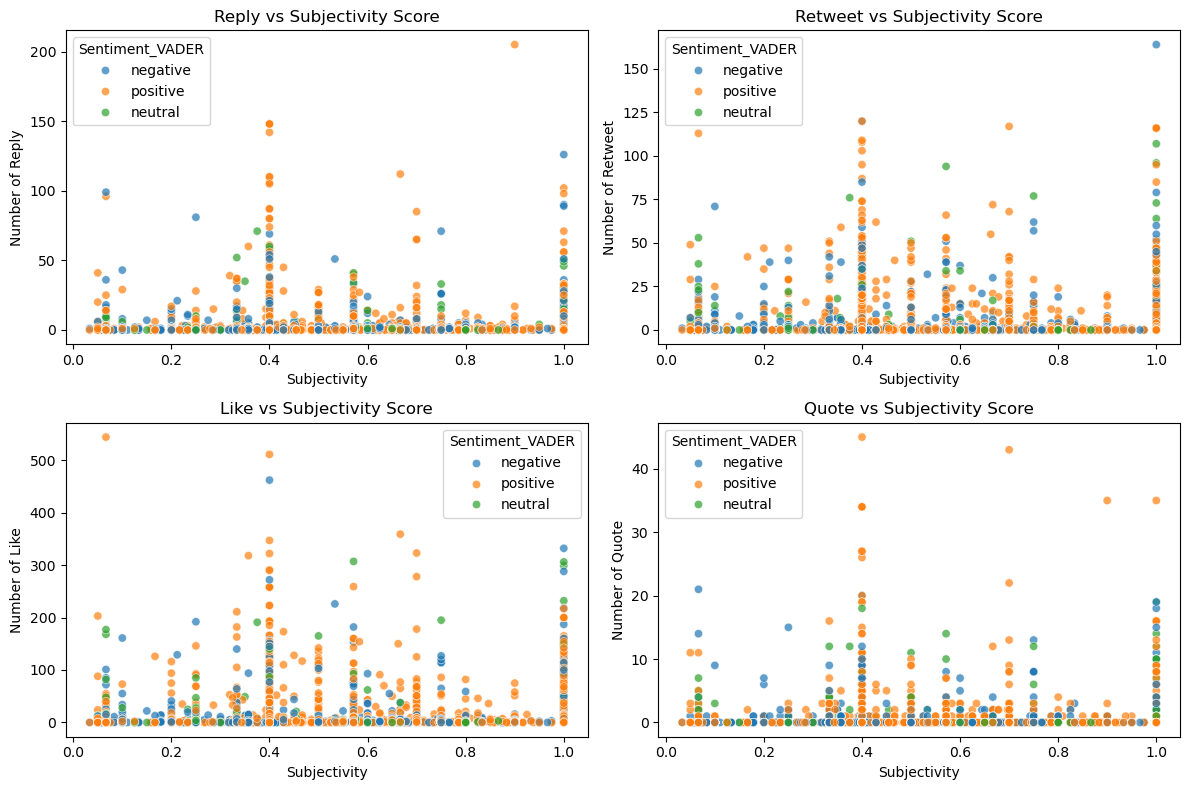

In [17]:
# Scatter plots: amplification metrics vs subjectivity score

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, metric in enumerate(['Reply', 'Retweet', 'Like', 'Quote']):
    sns.scatterplot(data=df[df['Subjectivity'] != 0], x='Subjectivity', y=metric,
                    hue='Sentiment_VADER', ax=axes[i], alpha=0.7)
    axes[i].set_title(f'{metric} vs Subjectivity Score')
    axes[i].set_ylabel(f'Number of {metric}')

plt.tight_layout()
plt.savefig('amplification_vs_subjectivity.pdf', bbox_inches='tight', pad_inches=.1);

## CamemBERT

In [18]:
# Install required packages if not already installed
# pip install transformers torch tqdm scipy
# pip install hf_xet
# pip install tf-keras

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import torch

CamemBERT models

- `cmarkea/distilcamembert-base-sentiment` — DistilCamemBERT fine-tuned for French sentiment (Amazon + Allociné). French-only sentiment model, smaller/efficient version.
- `cardiffnlp/camembert-base-tweet-sentiment-fr` — CamemBERT fine-tuned on French tweets (TweetSentimentMultilingual dataset, French subset). French tweet-specific sentiment model.
- `bardsai/finance-sentiment-fr-base` — CamemBERT-based model for French financial news sentiment (labels: positive, negative, neutral). Domain-specific (finance) French sentiment.
- `visalkao/sentiment-analysis-french` — CamemBERT-based French sentiment model (product reviews). General French sentiment model (product review domain).
- `ac0hik/Sentiment_Analysis_French` — CamemBERT (CamemBERT-base) fine‐tuned for French tweet sentiment (accuracy ~0.765). French tweet sentiment classification using CamemBERT.
- `astrosbd/french_emotion_camembert` — CamemBERT fine-tuned for French emotion classification (joy, sadness, anger, etc.). Broader than simple positive/negative sentiment.
- `kykyDeBondy/camembert-sentiment-analysis` — CamemBERT-base fine-tuned for sentiment/emotion. Specific emotions/sentiments, designed for sentiment/emotion classification.

In [19]:
# Use a French sentiment analysis model

MODEL = "cardiffnlp/camembert-base-tweet-sentiment-fr"        # "almanach/camembert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

In [20]:
def analyze_french_sentiment(text):
    """
    Analyze French text for sentiment polarity
    Returns: polarity_label, polarity_confidence
    """
    # Tokenize the text
    encoded_text = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
    
    # Get model predictions
    with torch.no_grad():
        output = model(**encoded_text)
    
    # Apply softmax to get probabilities
    scores = torch.nn.functional.softmax(output.logits, dim=-1).numpy()[0]
    
    # Define label mapping for this specific model
    # This model typically uses: 0=negative, 1=neutral, 2=positive
    labels = ['negative', 'neutral', 'positive']
    
    # Get the predicted label and confidence
    predicted_label_idx = np.argmax(scores)
    polarity_label = labels[predicted_label_idx]
    polarity_confidence = scores[predicted_label_idx]
    
    return polarity_label, float(polarity_confidence)

In [21]:
# Analyze sentiment for each tweet using a CamemBERT model

# Initialize new columns
df['Sentiment_BERT'] = None
df['Polarity_Confidence'] = None

for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row['Comment']
        
        # Get sentiment analysis results
        polarity_label, polarity_confidence = analyze_french_sentiment(text)
        
        # Store results directly in the DataFrame
        df.at[i, 'Sentiment_BERT'] = polarity_label
        df.at[i, 'Polarity_Confidence'] = round(polarity_confidence, 4)
        
    except Exception as e:
        print(f"Error processing tweet {i}: {str(e)}")
        # Store error markers
        df.at[i, 'Sentiment_BERT'] = 'error'
        df.at[i, 'Polarity_Confidence'] = 0.0

100%|██████████| 56219/56219 [1:05:21<00:00, 14.33it/s]


In [22]:
display(df["Sentiment_BERT"].value_counts(normalize = True))

Sentiment_BERT
negative    0.494281
neutral     0.357939
positive    0.147779
Name: proportion, dtype: float64

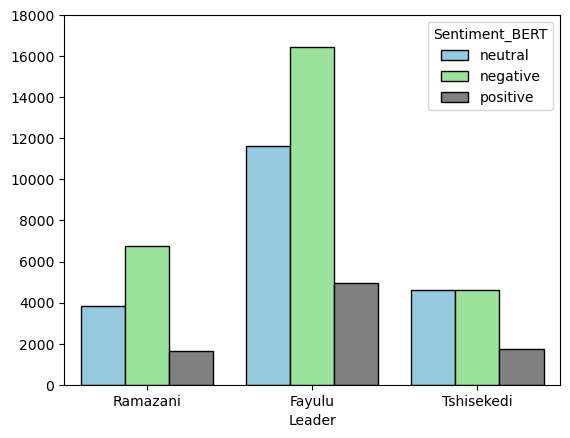

In [23]:
# Sentiment plot (1/4)

#plt.style.use('classic')
sns.countplot(data=df, x='Leader', hue='Sentiment_BERT', palette=['skyblue', 'lightgreen', 'gray'], edgecolor='black')
plt.ylim(0,18000)
plt.ylabel('');

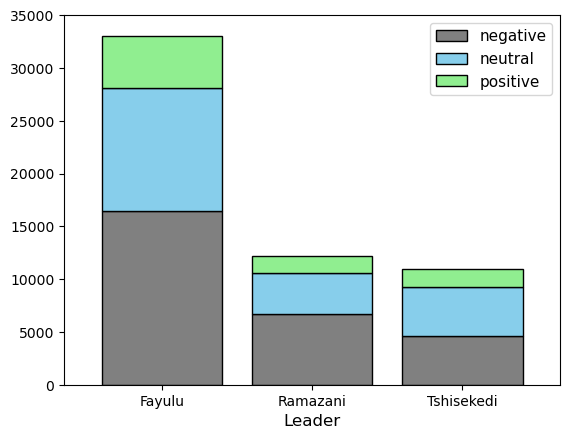

In [47]:
# Sentiment plot (2/4)

data_pivot = df.pivot_table(values = 'Quote', index='Leader', columns='Sentiment_BERT', aggfunc = "count")
data_pivot.plot(kind = 'bar', stacked = True, color = ['gray', 'skyblue', 'lightgreen'], edgecolor='black', width=0.8)
#plt.title('Cumulative number of tweets by sentiment type per leader', fontsize = 9, fontstyle = 'oblique', weight = 'bold')
plt.xticks(rotation = 360)
plt.ylim(0, 35000)
plt.xlabel('Leader', fontsize=12)
plt.legend(title='', fontsize=11)
plt.savefig('cumulative_number_of_tweets_following_the_sentiment_nature_BERT.pdf', bbox_inches='tight', pad_inches=.1);

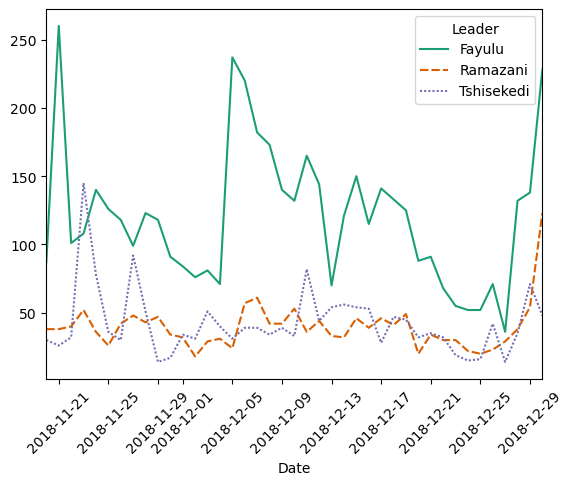

In [25]:
# Sentiment plot (3/4)

sns.lineplot(data = df.loc[df['Sentiment_BERT'] == 'positive'].pivot_table(values = "Quote", columns = "Leader",
                                                                      index = "Date", aggfunc = "count"),
             palette = 'Dark2')
#plt.title('Evolution du nombre de tweets positifs par leader')
plt.xticks(rotation=45)
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.savefig('evolution_of_the_number_of_positive_tweets_BERT.pdf', bbox_inches = 'tight', pad_inches = .1);

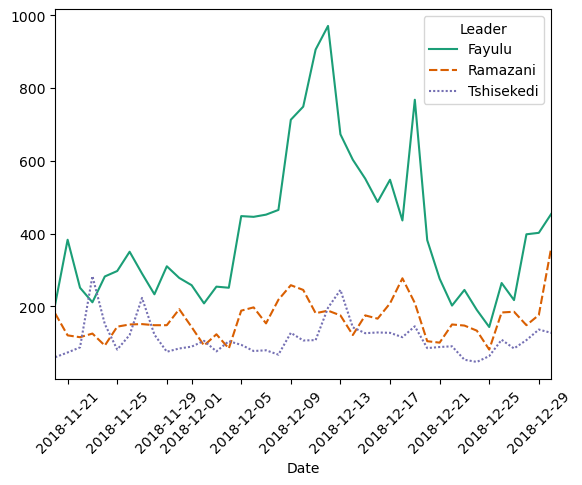

In [26]:
# Sentiment plot (4/4)

sns.lineplot(data = df.loc[df['Sentiment_BERT'] == 'negative'].pivot_table(values = "Quote", columns = "Leader",
                                                                      index = "Date", aggfunc = "count"),
             palette = 'Dark2')
#plt.title('Evolution du nombre de tweets negatifs par leader')
plt.xticks(rotation=45)
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.savefig('evolution_of_the_number_of_negative_tweets_BERT.pdf', bbox_inches = 'tight', pad_inches = .1);

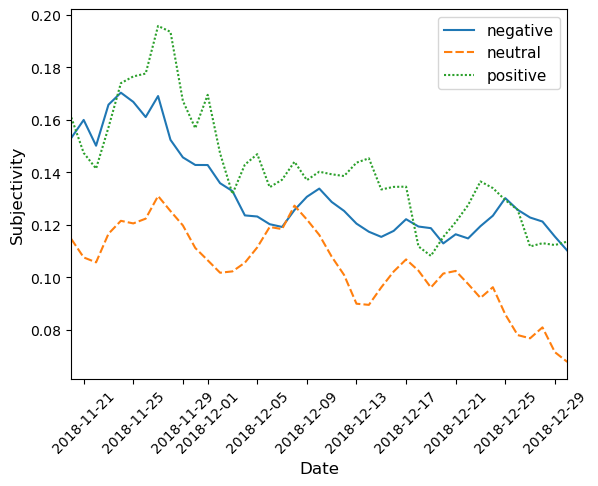

In [46]:
# Calculate 5-day moving average subjectivity per sentiment

ma_by_sentiment_bert=moving_average_subjectivity(df,group_col='Sentiment_BERT',window=5,step=1,align='right')

sns.lineplot(data=ma_by_sentiment_bert, palette='tab10')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.legend(fontsize=11, title='')
plt.ylabel('Subjectivity', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.xticks(rotation=45)
plt.savefig('ma_subjectivity_per_sentiment_bert.pdf', bbox_inches='tight', pad_inches=.1);

## Exporting the data

In [28]:
# Exporting the data
output_path = 'sentiment_data.csv'
df.to_csv(output_path, index=False)
print(f"\nDataFrame successfully exported to: {output_path}")


DataFrame successfully exported to: sentiment_data.csv
